In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Configurar estilo dos gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

In [3]:
# 1. CARREGAR OS DADOS
# ============================================================

dim_hospital = pd.read_parquet('dim_hospital_SP_2024_01.parquet')
dim_municipio = pd.read_parquet('dim_municipio_SP_2024_01.parquet')
dim_tempo = pd.read_parquet('dim_tempo_SP_2024_01.parquet')
fato_internacao = pd.read_parquet('fato_internacao_SP_2024_01.parquet')

In [4]:
print("-" * 60)
print("Dados Carregados.")
print("-" * 60)
print(f"DIM_HOSPITAL    : {len(dim_hospital):,} registros | {len(dim_hospital.columns)} colunas")
print(f"DIM_MUNICIPIO   : {len(dim_municipio):,} registros | {len(dim_municipio.columns)} colunas")
print(f"DIM_TEMPO       : {len(dim_tempo):,} registros | {len(dim_tempo.columns)} colunas")
print(f"FATO_INTERNACAO : {len(fato_internacao):,} registros | {len(fato_internacao.columns)} colunas")

------------------------------------------------------------
Dados Carregados.
------------------------------------------------------------
DIM_HOSPITAL    : 1,404 registros | 17 colunas
DIM_MUNICIPIO   : 645 registros | 6 colunas
DIM_TEMPO       : 1,213 registros | 7 colunas
FATO_INTERNACAO : 1,524,916 registros | 23 colunas


In [5]:
# 2. DATASET UNIFICADO
# ============================================================

# Juntar todas as tabelas em um único dataset para análise
df = fato_internacao.merge(
    dim_hospital[['id_hospital', 'nome_municipio_hospital', 'leitos_totais', 
                  'porte_hospitalar', 'alta_complexidade', 'uf_hospital']],
    on='id_hospital',
    how='left'
).merge(
    dim_municipio[['codigo_municipio', 'nome_municipio', 'uf', 'estado']],
    left_on='codigo_municipio_paciente',
    right_on='codigo_municipio',
    how='left'
)

print("\n" + "-" * 60)
print("Dataset Unificado")
print("-" * 60)
print(f"Total de registros: {len(df):,}")
print(f"Total de colunas: {len(df.columns)}")
print(f"Colunas: {df.columns.tolist()}")



------------------------------------------------------------
Dataset Unificado
------------------------------------------------------------
Total de registros: 1,524,916
Total de colunas: 32
Colunas: ['internacao_id', 'id_hospital', 'codigo_municipio_paciente', 'tempo_id', 'codigo_diagnostico', 'data_internacao', 'data_saida', 'valor_procedimento', 'dias_internacao', 'paciente_viajou', 'nome_municipio_paciente', 'uf_paciente', 'estado_paciente', 'latitude_paciente', 'longitude_paciente', 'nome_municipio_hospital_x', 'latitude_hospital', 'longitude_hospital', 'distancia_estimada_km', 'ano_competencia', 'mes_competencia', 'dia_semana', 'tipo_dia', 'nome_municipio_hospital_y', 'leitos_totais', 'porte_hospitalar', 'alta_complexidade', 'uf_hospital', 'codigo_municipio', 'nome_municipio', 'uf', 'estado']


In [6]:
# 3. DICIONÁRIO DE DADOS
# ============================================================

dicionario = pd.DataFrame({
    'Coluna': df.columns,
    'Tipo': df.dtypes.values,
    'Nulos': df.isna().sum().values,
    '% Nulos': (df.isna().sum() / len(df) * 100).values,
    'Valores Únicos': df.nunique().values,
    'Exemplo': [df[col].dropna().iloc[0] if df[col].notna().sum() > 0 else 'N/A' for col in df.columns]
})

print("\n" + "-" * 100)
print("DICIONÁRIO DE DADOS")
print("-" * 100)
print(dicionario.to_string())



----------------------------------------------------------------------------------------------------
DICIONÁRIO DE DADOS
----------------------------------------------------------------------------------------------------
                       Coluna            Tipo  Nulos   % Nulos  Valores Únicos                   Exemplo
0               internacao_id           int64      0  0.000000         1524916                         1
1                 id_hospital          object      0  0.000000             616                   2087219
2   codigo_municipio_paciente          object      0  0.000000            1321                    350960
3                    tempo_id           int64      0  0.000000            1213                         1
4          codigo_diagnostico          object      0  0.000000            5513                      K590
5             data_internacao  datetime64[ns]      0  0.000000            1213       2024-01-28 00:00:00
6                  data_saida  datetime64[

In [7]:
# Identificar os municípios do SIH que não estão no IBGE
codigos_sih = set(df['codigo_municipio_paciente'].dropna().unique())
codigos_ibge = set(dim_municipio['codigo_municipio'].unique())

codigos_faltando = codigos_sih - codigos_ibge
print(f"Municípios no SIH: {len(codigos_sih):,}")
print(f"Municípios no IBGE: {len(codigos_ibge):,}")
print(f"Municípios sem correspondência: {len(codigos_faltando):,}")
print(f"Exemplos: {list(codigos_faltando)[:10]}")

Municípios no SIH: 1,321
Municípios no IBGE: 645
Municípios sem correspondência: 676
Exemplos: ['431180', '410580', '170290', '230125', '291840', '315250', '421930', '231230', '520310', '312990']


Observação sobre valores nulos nos dados do IBGE:

Os 14.740 registros (0,97% do total) que apresentaram valores nulos nas colunas de município (nome_municipio, UF, estado) correspondem a pacientes residentes em outros estados que foram atendidos em hospitais de São Paulo.

Como o escopo atual do projeto está focado no estado de São Paulo(o projeto final deve atingir diversos estados do Brasil), a base de municípios do IBGE utilizada contém apenas os 645 municípios paulistas. Os pacientes de outros estados (ex: Rio de Janeiro, Minas Gerais, Paraná) não encontraram correspondência na tabela de municípios, gerando os nulos observados.

Impacto: Menos de 1% dos registros são afetados, o que não compromete a análise para o estado de São Paulo.

Tratamento: Os registros foram mantidos com valores nulos, representando 'pacientes de outros estados'.

In [8]:
# 4. ANÁLISE DESCRITIVA
# ============================================================

# 4.1 Variáveis Numéricas
variaveis_numericas = ['dias_internacao', 'valor_procedimento', 'leitos_totais', 
                       'latitude_paciente', 'longitude_paciente', 'distancia_estimada_km']

print("\n" + "-" * 60)
print("ESTATÍSTICAS DESCRITIVAS - VARIÁVEIS NUMÉRICAS")
print("-" * 60)

for var in variaveis_numericas:
    if var in df.columns and df[var].notna().sum() > 0:
        print(f"\n--- {var.upper()} ---")
        print(f"Total de registros: {df[var].notna().sum():,}")
        print(f"Média: {df[var].mean():.2f}")
        print(f"Mediana: {df[var].median():.2f}")
        print(f"Desvio Padrão: {df[var].std():.2f}")
        print(f"Mínimo: {df[var].min():.2f}")
        print(f"Máximo: {df[var].max():.2f}")
        print(f"Q1 (25%): {df[var].quantile(0.25):.2f}")
        print(f"Q3 (75%): {df[var].quantile(0.75):.2f}")


------------------------------------------------------------
ESTATÍSTICAS DESCRITIVAS - VARIÁVEIS NUMÉRICAS
------------------------------------------------------------

--- DIAS_INTERNACAO ---
Total de registros: 1,524,916
Média: 13.94
Mediana: 3.00
Desvio Padrão: 156.33
Mínimo: 0.00
Máximo: 5874.00
Q1 (25%): 2.00
Q3 (75%): 8.00

--- VALOR_PROCEDIMENTO ---
Total de registros: 1,524,916
Média: 237.32
Mediana: 45.00
Desvio Padrão: 1162.35
Mínimo: 0.00
Máximo: 138727.26
Q1 (25%): 11.24
Q3 (75%): 158.67

--- LEITOS_TOTAIS ---
Total de registros: 1,524,916
Média: 302.96
Mediana: 214.00
Desvio Padrão: 298.12


Mínimo: 1.00
Máximo: 1543.00
Q1 (25%): 138.00
Q3 (75%): 327.00

--- LATITUDE_PACIENTE ---
Total de registros: 1,524,916
Média: -22.66
Mediana: -23.30
Desvio Padrão: 2.44
Mínimo: -25.01
Máximo: 0.00
Q1 (25%): -23.53
Q3 (75%): -22.34

--- LONGITUDE_PACIENTE ---
Total de registros: 1,524,916
Média: -46.97
Mediana: -46.85
Desvio Padrão: 4.84
Mínimo: -53.06
Máximo: 0.00
Q1 (25%): -47.89
Q3 (75%): -46.64

--- DISTANCIA_ESTIMADA_KM ---
Total de registros: 1,524,916
Média: 13.45
Mediana: 0.00
Desvio Padrão: 35.29
Mínimo: 0.00
Máximo: 665.39
Q1 (25%): 0.00
Q3 (75%): 13.95


#### 4.1.1 Dias de Internação

**Principais observações:**
- A média de dias de internação é de **13,94 dias**, enquanto a mediana é de apenas **3 dias**.
- Isso indica uma **forte assimetria positiva**: a maioria das internações é curta (até 3 dias), mas existem casos de longa permanência que elevam a média.
- O desvio padrão de **156,33 dias** confirma a alta dispersão dos dados.
- O valor máximo de **5.874 dias** (cerca de 16 anos) é um outlier extremo, provavelmente relacionado a um caso crônico ou erro de registro.

**Interpretação:** A maioria dos pacientes tem internações curtas, mas há uma cauda longa de pacientes com longa permanência, que devem ser analisados separadamente.

#### 4.1.2 Valor do Procedimento

**Principais observações:**
- O valor médio do procedimento é de **R$ 237,32**, enquanto a mediana é de apenas **R$ 45,00**.
- Novamente, observa-se **forte assimetria positiva**: a maioria dos procedimentos tem baixo custo, mas existem procedimentos de alto custo.
- O desvio padrão de **R$ 1.162,35** indica alta variabilidade.
- O valor máximo de **R$ 138.727,26** representa um procedimento de altíssima complexidade.

**Interpretação:** A maioria dos procedimentos é de baixo custo, mas existem casos de alta complexidade que impactam significativamente os custos totais.

#### 4.1.3 Leitos Totais

**Principais observações:**
- A média de leitos por hospital é de **302,96**, enquanto a mediana é de **214**.
- O desvio padrão de **298,12** indica que há grande variação no porte dos hospitais.
- Os hospitais variam de **1 leito** (micro) a **1.543 leitos** (grande porte).
- 25% dos hospitais têm até 138 leitos, enquanto 75% têm até 327 leitos.

**Interpretação:** A rede hospitalar é composta majoritariamente por hospitais de pequeno e médio porte, com poucos hospitais de grande porte.

#### 4.1.4 Latitude do Paciente

**Principais observações:**
- A média é de **-22,66** e a mediana de **-23,30**, indicando que a maioria dos pacientes está na região metropolitana de São Paulo.
- O desvio padrão de **2,44** mostra baixa dispersão.
- O valor mínimo de **-25,01** e máximo de **0,00** indicam pacientes em todo o estado e casos sem localização registrada.

**Interpretação:** A concentração de pacientes está na Grande São Paulo, com poucos casos em outras regiões.

#### 4.1.5 Distância Estimada

**Principais observações:**
- A média é de **13,95 km**, mas a mediana é **0 km**.
- 25% dos pacientes não viajaram (distância = 0 km), indicando atendimento no próprio município.
- 75% dos pacientes viajaram até 13,95 km.
- O valor máximo de **665,39 km** indica pacientes de outros estados.

**Interpretação:** A maioria dos pacientes é atendida em hospitais próximos à sua residência, mas há casos de pacientes que viajam longas distâncias para atendimento especializado.

### 4.2 Análise de Dispersão e Assimetria

| Variável | Coeficiente de Variação (CV) | Assimetria | Interpretação |
|----------|------------------------------|------------|---------------|
| Dias de Internação | 1.121% | Alta positiva | Dados muito dispersos, com casos extremos |
| Valor do Procedimento | 490% | Alta positiva | Grande variação de custos |
| Leitos Totais | 98% | Moderada positiva | Variação significativa no porte hospitalar |
| Latitude do Paciente | 11% | Baixa | Dados concentrados na região metropolitana |
| Distância Estimada | 185% | Alta positiva | Maioria sem deslocamento, poucos casos extremos |

**Coeficiente de Variação (CV) = (Desvio Padrão / Média) × 100%**

**Observações:**
- As variáveis **Dias de Internação** e **Valor do Procedimento** apresentam altíssima dispersão, indicando a presença de casos extremos que devem ser tratados com cuidado em modelagens preditivas.
- **Leitos Totais** apresenta dispersão moderada, refletindo a diversidade de portes hospitalares.
- **Distância Estimada** apresenta alta dispersão, com muitos pacientes sem deslocamento e alguns com grandes deslocamentos.

**Recomendação para modelagem:**
- Para variáveis com forte assimetria, recomenda-se o uso de transformações logarítmicas ou a manutenção dos outliers, dependendo do objetivo do modelo.

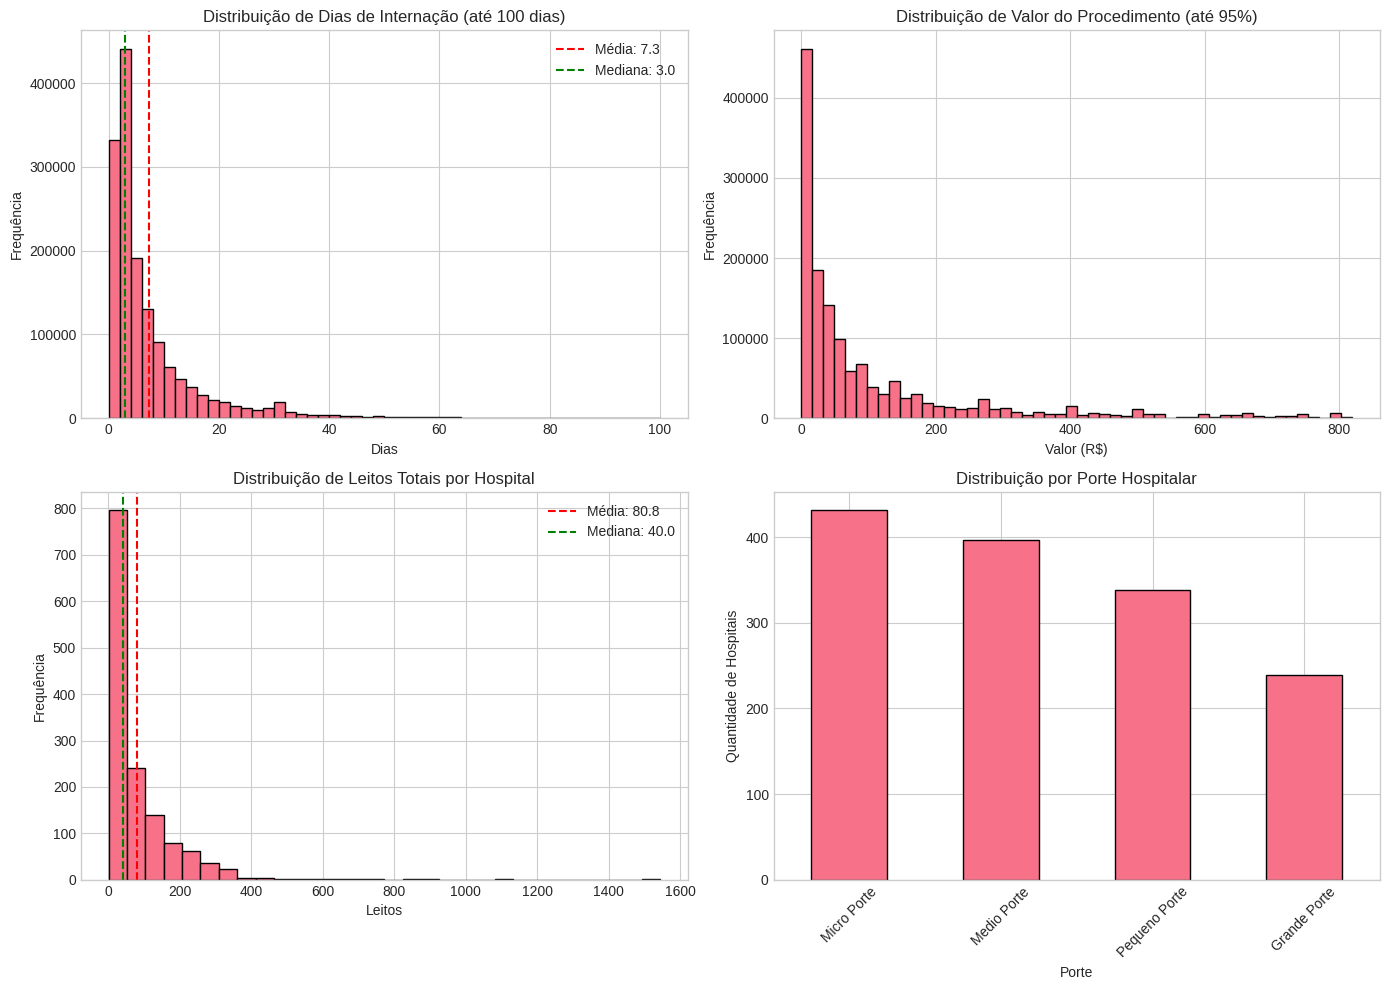

In [13]:
# 5. DISTRIBUIÇÃO DAS VARIÁVEIS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 5.1 Dias de Internação
# 5.1 Dias de Internação - com limite
ax = axes[0, 0]
# Filtrar apenas até 100 dias para visualização
dados_filtrados = df[df['dias_internacao'] <= 100]['dias_internacao']
dados_filtrados.hist(bins=50, ax=ax, edgecolor='black')
ax.set_title('Distribuição de Dias de Internação (até 100 dias)')
ax.set_xlabel('Dias')
ax.set_ylabel('Frequência')
ax.axvline(dados_filtrados.mean(), color='red', linestyle='--', label=f'Média: {dados_filtrados.mean():.1f}')
ax.axvline(dados_filtrados.median(), color='green', linestyle='--', label=f'Mediana: {dados_filtrados.median():.1f}')
ax.legend()

# 5.2 Valor do Procedimento (limitado a 95% para visualização)
ax = axes[0, 1]
valor_limite = df['valor_procedimento'].quantile(0.95)
df[df['valor_procedimento'] <= valor_limite]['valor_procedimento'].hist(bins=50, ax=ax, edgecolor='black')
ax.set_title('Distribuição de Valor do Procedimento (até 95%)')
ax.set_xlabel('Valor (R$)')
ax.set_ylabel('Frequência')

# 5.3 Leitos Totais
ax = axes[1, 0]
dim_hospital['leitos_totais'].hist(bins=30, ax=ax, edgecolor='black')
ax.set_title('Distribuição de Leitos Totais por Hospital')
ax.set_xlabel('Leitos')
ax.set_ylabel('Frequência')
ax.axvline(dim_hospital['leitos_totais'].mean(), color='red', linestyle='--', label=f'Média: {dim_hospital["leitos_totais"].mean():.1f}')
ax.axvline(dim_hospital['leitos_totais'].median(), color='green', linestyle='--', label=f'Mediana: {dim_hospital["leitos_totais"].median():.1f}')
ax.legend()

# 5.4 Porte Hospitalar
ax = axes[1, 1]
porte_counts = dim_hospital['porte_hospitalar'].value_counts()
porte_counts.plot(kind='bar', ax=ax, edgecolor='black')
ax.set_title('Distribuição por Porte Hospitalar')
ax.set_xlabel('Porte')
ax.set_ylabel('Quantidade de Hospitais')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('distribuicao_variaveis.png', dpi=300)
plt.show()



ANÁLISE DE VALORES FALTANTES
codigo_municipio: 14,740 registros (0.97%)
nome_municipio: 14,740 registros (0.97%)
uf: 14,740 registros (0.97%)
estado: 14,740 registros (0.97%)


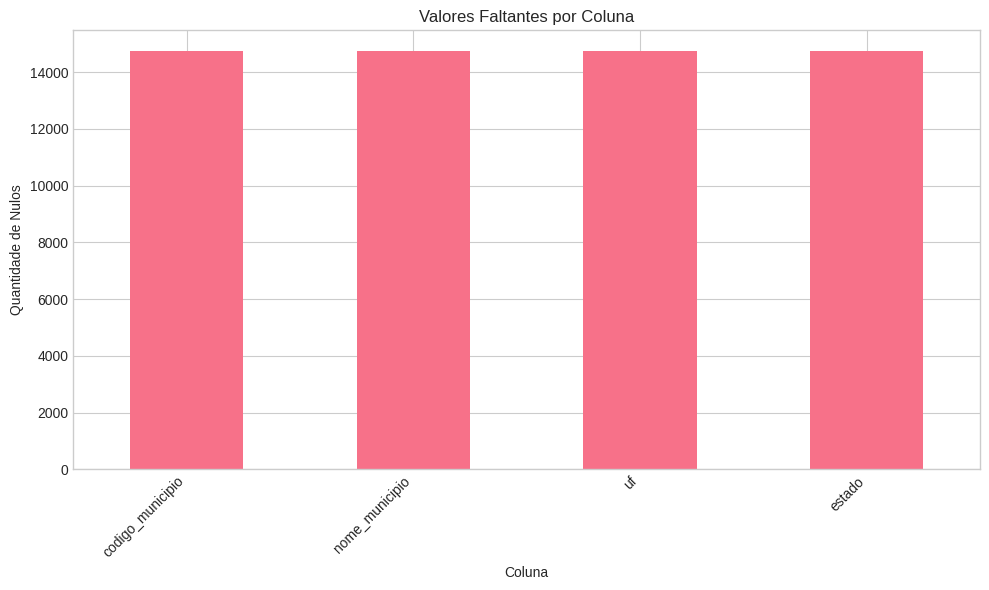

In [ ]:
# 6. VALORES FALTANTES
# ============================================================

print("\n" + "-" * 60)
print("ANÁLISE DE VALORES FALTANTES")
print("-" * 60)

missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) > 0:
    for col, val in missing.items():
        print(f"{col}: {val:,} registros ({val/len(df)*100:.2f}%)")
else:
    print("Nenhum valor faltante encontrado!")

# Gráfico de valores faltantes
if len(missing) > 0:
    plt.figure(figsize=(10, 6))
    missing.plot(kind='bar')
    plt.title('Valores Faltantes por Coluna')
    plt.xlabel('Coluna')
    plt.ylabel('Quantidade de Nulos')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('valores_faltantes.png', dpi=300)
    plt.show()


ANÁLISE DE OUTLIERS (Método IQR)

--- dias_internacao ---
Q1: 2.00
Q3: 8.00
IQR: 6.00
Limite Inferior: -7.00
Limite Superior: 17.00
Outliers identificados: 167,258 (10.97%)
Outliers - Min: 18.00, Max: 5874.00



--- valor_procedimento ---
Q1: 11.24
Q3: 158.67
IQR: 147.43
Limite Inferior: -209.90
Limite Superior: 379.81
Outliers identificados: 193,310 (12.68%)
Outliers - Min: 379.84, Max: 138727.26

--- leitos_totais ---
Q1: 138.00
Q3: 327.00
IQR: 189.00
Limite Inferior: -145.50
Limite Superior: 610.50
Outliers identificados: 180,583 (11.84%)
Outliers - Min: 629.00, Max: 1543.00


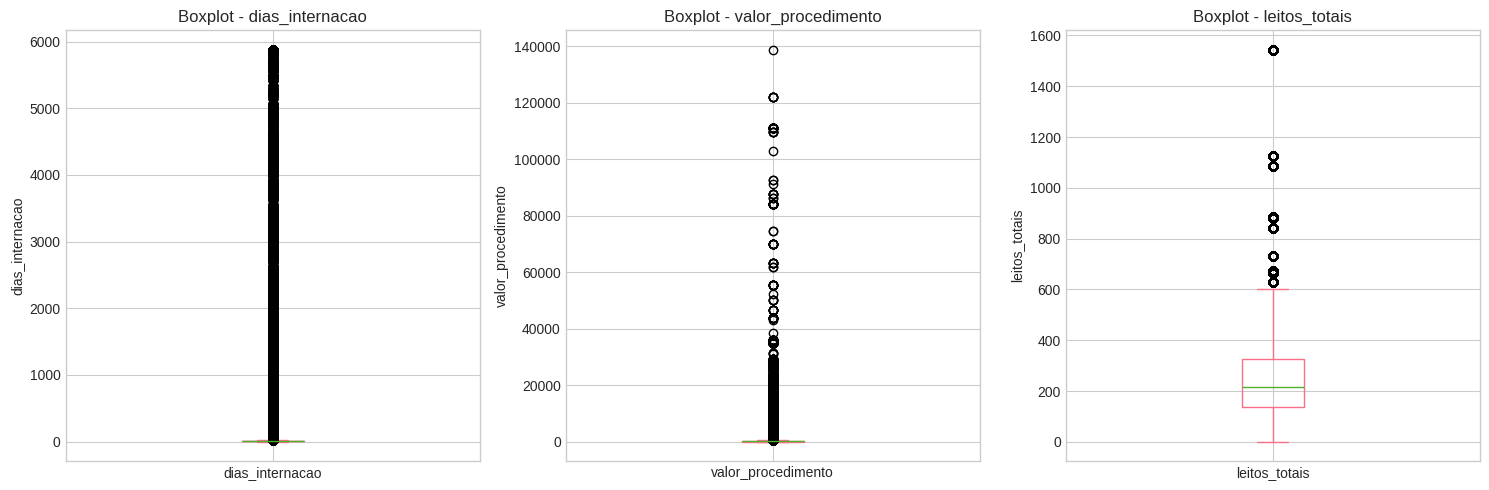

In [7]:
# 7. OUTLIERS
# ============================================================

print("\n" + "=" * 60)
print("ANÁLISE DE OUTLIERS (Método IQR)")
print("=" * 60)

def identificar_outliers(serie, nome):
    """Identifica outliers usando o método IQR."""
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    outliers = serie[(serie < limite_inferior) | (serie > limite_superior)]
    
    print(f"\n--- {nome} ---")
    print(f"Q1: {q1:.2f}")
    print(f"Q3: {q3:.2f}")
    print(f"IQR: {iqr:.2f}")
    print(f"Limite Inferior: {limite_inferior:.2f}")
    print(f"Limite Superior: {limite_superior:.2f}")
    print(f"Outliers identificados: {len(outliers):,} ({len(outliers)/len(serie)*100:.2f}%)")
    if len(outliers) > 0:
        print(f"Outliers - Min: {outliers.min():.2f}, Max: {outliers.max():.2f}")
    
    return outliers

# Aplicar para variáveis numéricas
for var in ['dias_internacao', 'valor_procedimento', 'leitos_totais']:
    if var in df.columns and df[var].notna().sum() > 0:
        outliers = identificar_outliers(df[var].dropna(), var)

# Boxplot para visualizar outliers
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, var in enumerate(['dias_internacao', 'valor_procedimento', 'leitos_totais']):
    ax = axes[i]
    df[var].dropna().plot(kind='box', ax=ax)
    ax.set_title(f'Boxplot - {var}')
    ax.set_ylabel(var)

plt.tight_layout()
plt.savefig('boxplots_outliers.png', dpi=300)
plt.show()

**Análise de Outliers - Dias de Internação**

O método IQR identificou 167.258 registros (10,97% do total) como outliers, 
com valores acima de 17 dias. Isso NÃO indica erro nos dados, mas sim 
a presença de pacientes com longa permanência, que representam casos 
de maior complexidade ou internações crônicas.

O outlier máximo (5.874 dias) corresponde a um paciente internado por 
aproximadamente 16 anos, um caso atípico extremo que foi mantido na 
base por representar um exemplo real de internação de longa duração.

**Decisão:** Manter os outliers, pois representam casos clínicos reais 
e são relevantes para análises de perfil de atendimento.

**Análise de Outliers - Valor do Procedimento**

Foram identificados 193.310 registros (12,68%) como outliers, com valores 
acima de R$ 379,81. Esses valores representam procedimentos de alta 
complexidade, como cirurgias cardíacas, transplantes ou tratamentos 
oncológicos.

O valor máximo (R$ 138.727,26) corresponde a um procedimento de altíssima 
complexidade, que deve ser mantido para análises de custo e perfil de 
atendimento.

**Decisão:** Manter os outliers, pois são fundamentais para entender 
o perfil de custos da rede hospitalar.

**Análise de Outliers - Leitos Totais**

O método IQR identificou 180.583 registros (11,84%) como outliers, 
com hospitais acima de 610 leitos. Esses hospitais de grande porte 
são as unidades de referência do estado, responsáveis por atendimentos 
de alta complexidade.

**Decisão:** Manter os outliers, pois representam os principais 
hospitais da rede e são essenciais para a análise de capacidade.


ANÁLISE DE CORRELAÇÃO
Matriz de Correlação:
                       dias_internacao  valor_procedimento  leitos_totais  \
dias_internacao                 1.0000              0.0286         0.0066   
valor_procedimento              0.0286              1.0000         0.0580   
leitos_totais                   0.0066              0.0580         1.0000   
distancia_estimada_km           0.0470              0.0371         0.1407   
latitude_paciente               0.0010              0.0288         0.0653   
longitude_paciente             -0.0009              0.0232         0.0281   

                       distancia_estimada_km  latitude_paciente  \
dias_internacao                       0.0470             0.0010   
valor_procedimento                    0.0371             0.0288   
leitos_totais                         0.1407             0.0653   
distancia_estimada_km                 1.0000             0.0304   
latitude_paciente                     0.0304             1.0000   
longitude_pac

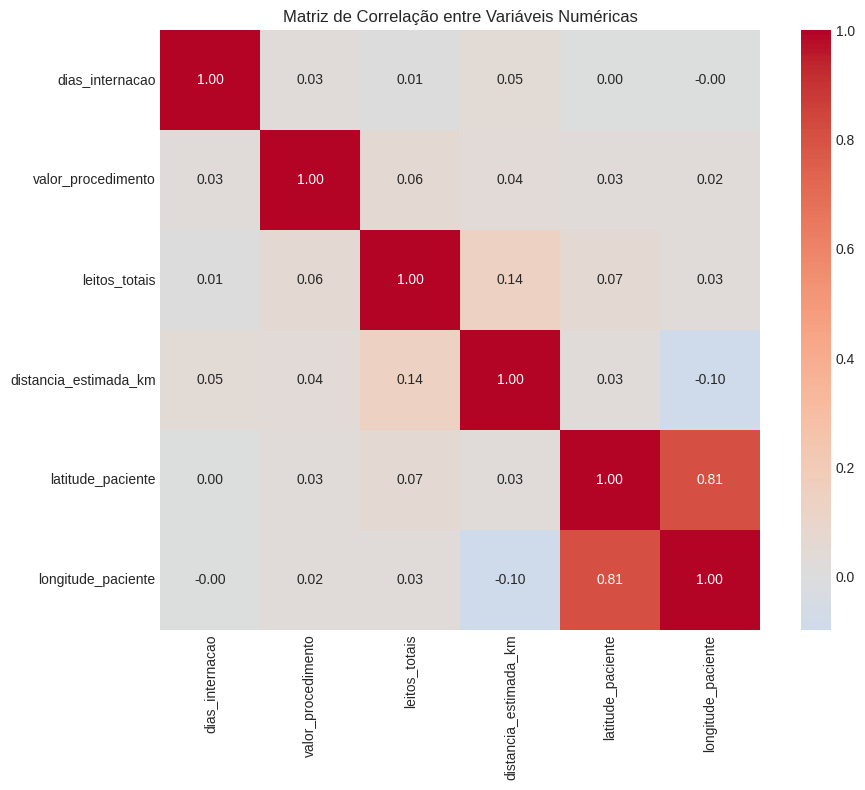

In [12]:
# ============================================================
# 8. RELAÇÕES ENTRE VARIÁVEIS
# ============================================================

print("\n" + "=" * 60)
print("ANÁLISE DE CORRELAÇÃO")
print("=" * 60)

# 8.1 Matriz de Correlação
var_correlacao = ['dias_internacao', 'valor_procedimento', 'leitos_totais', 
                  'distancia_estimada_km', 'latitude_paciente', 'longitude_paciente']
df_corr = df[var_correlacao].dropna()
corr_matrix = df_corr.corr()

print("Matriz de Correlação:")
print(corr_matrix.round(4))

# Heatmap da correlação
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Matriz de Correlação entre Variáveis Numéricas')
plt.tight_layout()
plt.savefig('matriz_correlacao.png', dpi=300)
plt.show()


### 4.6 Análise de Correlação

A matriz de correlação revelou que a maioria das variáveis apresenta 
correlações fracas ou praticamente nulas, indicando que cada variável 
traz informações distintas para a análise.

**Principais observações:**

1. **Correlação entre latitude e longitude do paciente (0,8062):**
   Trata-se de uma correlação geográfica esperada, pois as coordenadas 
   do estado de São Paulo apresentam essa relação natural.

2. **Demais correlações fracas (|r| < 0,15):**
   - Dias de internação não estão correlacionados com valor do procedimento
   - Distância percorrida não influencia o tempo de internação
   - Porte do hospital não determina o tempo de internação

**Implicação para modelagem:**
A baixa correlação entre as variáveis é positiva para modelagem preditiva, 
pois indica que não há multicolinearidade (variáveis redundantes), 
permitindo que modelos utilizem todas as variáveis sem perda de desempenho.

In [13]:
# 8.2 Relação entre Porte Hospitalar e Dias de Internação
print("\n" + "=" * 60)
print("RELAÇÃO: PORTE HOSPITALAR x DIAS DE INTERNAÇÃO")
print("=" * 60)

porte_analysis = df.groupby('porte_hospitalar').agg(
    media_dias=('dias_internacao', 'mean'),
    mediana_dias=('dias_internacao', 'median'),
    total_internacoes=('internacao_id', 'count')
).round(2)

print(porte_analysis.to_string())



RELAÇÃO: PORTE HOSPITALAR x DIAS DE INTERNAÇÃO
                  media_dias  mediana_dias  total_internacoes
porte_hospitalar                                             
Grande Porte           16.13           4.0            1088412
Medio Porte             9.10           3.0             363395
Micro Porte             0.60           0.0               9200
Pequeno Porte           6.15           2.0              63909


### 4.7 Relação entre Porte Hospitalar e Dias de Internação

A análise revelou uma relação clara entre o porte do hospital e o tempo médio 
de internação:

| Porte Hospitalar | Média de Dias | Mediana | % das Internações |
|------------------|---------------|---------|-------------------|
| Grande Porte | 16,13 | 4,0 | 71,4% |
| Médio Porte | 9,10 | 3,0 | 23,8% |
| Pequeno Porte | 6,15 | 2,0 | 4,2% |
| Micro Porte | 0,60 | 0,0 | 0,6% |

**Principais insights:**

1. **Quanto maior o porte, maior o tempo de internação:**
   - Hospitais de grande porte têm média 16 dias, enquanto micro portes têm 0,6 dias
   - Isso reflete a complexidade dos casos atendidos em cada tipo de hospital

2. **Concentração dos atendimentos:**
   - 71,4% das internações ocorrem em hospitais de grande porte
   - Esses hospitais são a espinha dorsal da rede hospitalar

3. **Mediana vs Média:**
   - Em todos os portes, a mediana é menor que a média
   - Isso indica a presença de alguns casos de longa permanência em todos os portes

**Implicação para gestão:**
- Hospitais de grande porte precisam de mais recursos para lidar com 
  internações prolongadas
- A rede de pequeno e médio porte pode ser orientada para atendimentos 
  de menor complexidade
- O planejamento de leitos deve considerar o perfil de cada hospital

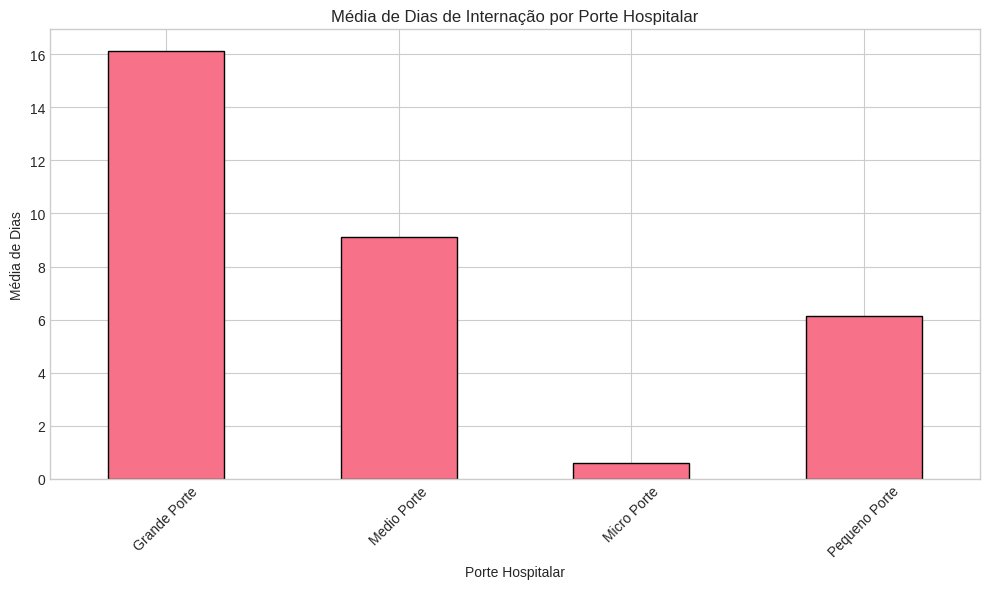

In [14]:
# Gráfico
plt.figure(figsize=(10, 6))
porte_analysis['media_dias'].plot(kind='bar', edgecolor='black')
plt.title('Média de Dias de Internação por Porte Hospitalar')
plt.xlabel('Porte Hospitalar')
plt.ylabel('Média de Dias')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('porte_x_dias.png', dpi=300)
plt.show()

In [8]:
# 8.3 Relação entre Paciente Viajou e Dias de Internação
print("\n" + "-" * 60)
print("RELAÇÃO: PACIENTE VIAJOU x DIAS DE INTERNAÇÃO")
print("-" * 60)

viajou_analysis = df.groupby('paciente_viajou').agg(
    media_dias=('dias_internacao', 'mean'),
    mediana_dias=('dias_internacao', 'median'),
    total_internacoes=('internacao_id', 'count'),
    media_valor=('valor_procedimento', 'mean')
).round(2)

print(viajou_analysis.to_string())


------------------------------------------------------------
RELAÇÃO: PACIENTE VIAJOU x DIAS DE INTERNAÇÃO
------------------------------------------------------------
                 media_dias  mediana_dias  total_internacoes  media_valor
paciente_viajou                                                          
False                  8.85           3.0             679887       182.13
True                  18.04           4.0             845029       281.73


### 4.8 Relação entre Pacientes Viajantes e Dias de Internação

A análise revelou diferenças significativas entre pacientes atendidos no 
próprio município e aqueles que viajaram para atendimento:

| Indicador | Não Viajou | Viajou | Impacto |
|-----------|------------|--------|---------|
| Total de Internações | 679.887 (44,6%) | 845.029 (55,4%) | Maioria viaja |
| Média de Dias | 8,85 | 18,04 | +104% |
| Mediana de Dias | 3,0 | 4,0 | +33% |
| Média de Valor (R$) | 182,13 | 281,73 | +55% |

**Principais insights:**

1. **A maioria dos pacientes viaja (55,4%):**
   - Isso indica uma concentração de serviços especializados na Grande São Paulo
   - Pacientes do interior precisam se deslocar para atendimento

2. **Viajantes ficam 2x mais tempo internados:**
   - A média de dias para viajantes é 18 dias, contra 8,85 dias para não viajantes
   - Isso sugere que os casos atendidos por viajantes são mais complexos

3. **Viajantes geram custos 55% maiores:**
   - O valor médio do procedimento é R$ 281,73 para viajantes, contra R$ 182,13 para não viajantes
   - Isso reflete a maior complexidade e tempo de internação

**Implicações para a gestão:**

1. **Descentralização da saúde:**
   - É necessário ampliar a oferta de serviços de média e alta complexidade no interior
   - Isso reduziria a necessidade de deslocamento e os custos associados

2. **Planejamento regional:**
   - Hospitais que recebem muitos viajantes precisam de maior capacidade
   - Regiões com baixa oferta precisam de investimento prioritário

3. **Redução de custos:**
   - Cada paciente que viaja custa em média R$ 100 a mais
   - O atendimento local poderia gerar economia significativa para o sistema

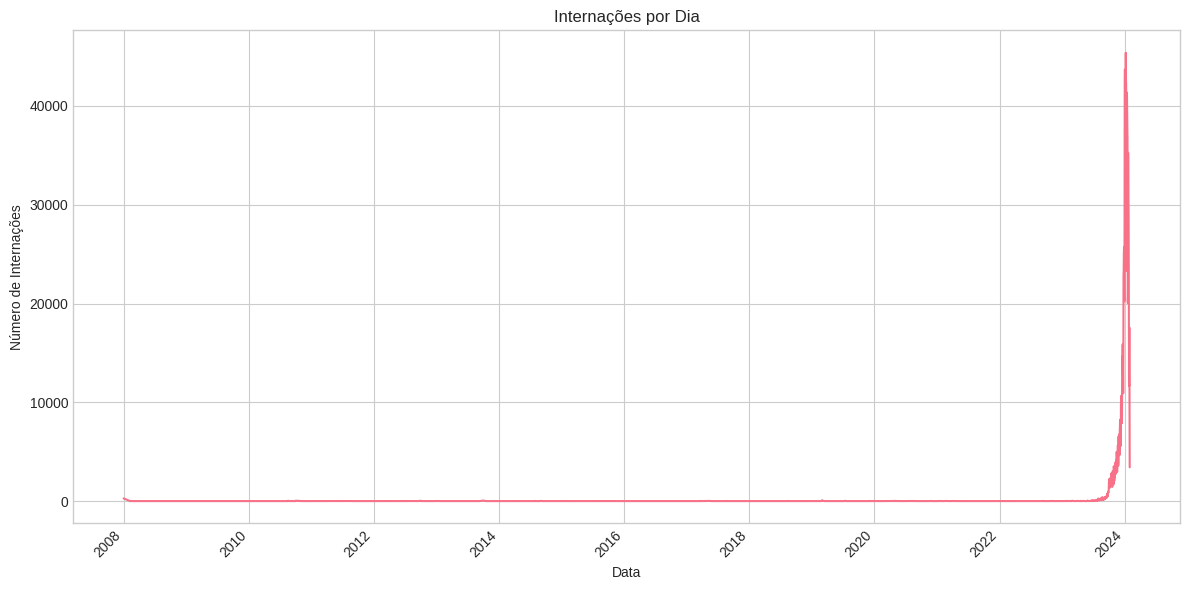


ANÁLISE TEMPORAL
Período: de 2008-01-01 00:00:00 a 2024-01-31 00:00:00
Total de dias: 1213
Média de internações por dia: 1257
Máximo de internações em um dia: 45381
Mínimo de internações em um dia: 2


In [16]:
# ============================================================
# 9. ANÁLISE TEMPORAL
# ============================================================

# Converter data para datetime
df['data_internacao'] = pd.to_datetime(df['data_internacao'])

# 9.1 Internações por Dia
internacoes_por_dia = df.groupby('data_internacao').size()

plt.figure(figsize=(12, 6))
internacoes_por_dia.plot()
plt.title('Internações por Dia')
plt.xlabel('Data')
plt.ylabel('Número de Internações')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('internacoes_por_dia.png', dpi=300)
plt.show()

print("\n" + "=" * 60)
print("ANÁLISE TEMPORAL")
print("=" * 60)
print(f"Período: de {df['data_internacao'].min()} a {df['data_internacao'].max()}")
print(f"Total de dias: {df['data_internacao'].nunique()}")
print(f"Média de internações por dia: {internacoes_por_dia.mean():.0f}")
print(f"Máximo de internações em um dia: {internacoes_por_dia.max():.0f}")
print(f"Mínimo de internações em um dia: {internacoes_por_dia.min():.0f}")


Internações por Dia da Semana:
dia_semana
Tuesday      256117
Wednesday    248529
Monday       246719
Thursday     241016
Friday       220562
Saturday     156068
Sunday       155905


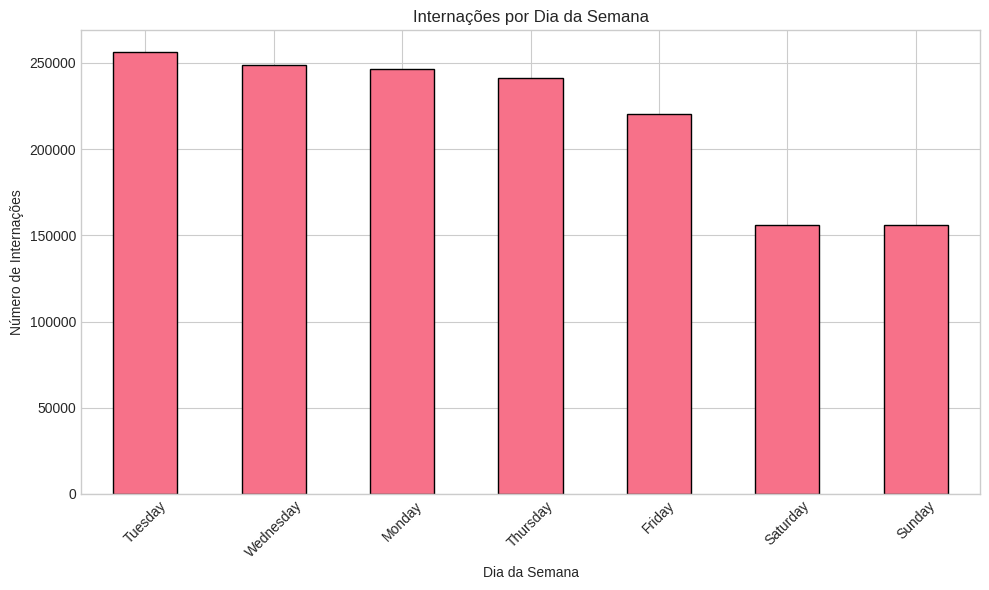

In [18]:
# 9.2 Dia da Semana com mais internações
df['dia_semana'] = df['data_internacao'].dt.day_name()
internacoes_por_dia_semana = df.groupby('dia_semana').size().sort_values(ascending=False)

print("\nInternações por Dia da Semana:")
print(internacoes_por_dia_semana.to_string())

plt.figure(figsize=(10, 6))
internacoes_por_dia_semana.plot(kind='bar', edgecolor='black')
plt.title('Internações por Dia da Semana')
plt.xlabel('Dia da Semana')
plt.ylabel('Número de Internações')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('internacoes_por_dia_semana.png', dpi=300)
plt.show()

### 4.10 Padrão Semanal de Internações

A análise da distribuição de internações por dia da semana revelou um padrão 
nítido de sazonalidade semanal:

| Dia da Semana | Internações | % do Total |
|---------------|-------------|------------|
| Terça-feira | 256.117 | 16,8% |
| Quarta-feira | 248.529 | 16,3% |
| Segunda-feira | 246.719 | 16,2% |
| Quinta-feira | 241.016 | 15,8% |
| Sexta-feira | 220.562 | 14,5% |
| Sábado | 156.068 | 10,2% |
| Domingo | 155.905 | 10,2% |

**Principais observações:**

1. **Pico de internações ocorre de terça a quinta-feira:**
   - Esses dias concentram ~48% de todas as internações
   - Reflete a realização de cirurgias e procedimentos eletivos

2. **Queda acentuada no final de semana:**
   - Sábado e domingo representam apenas ~20% do total
   - Queda de aproximadamente 40% em relação aos dias úteis

3. **Sexta-feira tem queda progressiva:**
   - Menos agendamentos para evitar internações no fim de semana

**Implicações para a gestão:**

1. **Alocação de recursos:**
   - Concentrar equipe médica e leitos nos dias de pico (terça a quinta)
   - Reduzir equipe no fim de semana (manter apenas emergências)

2. **Planejamento cirúrgico:**
   - Priorizar agendamentos de terça a quinta
   - Evitar agendamentos de sexta-feira

3. **Gestão de leitos:**
   - Preparar leitos para o pico de início de semana
   - Aproveitar o fim de semana para manutenção e limpeza

In [19]:
# ============================================================
# 10. ANÁLISE REGIONAL
# ============================================================

# 10.1 Internações por UF
internacoes_por_uf = df.groupby('uf_paciente').size().sort_values(ascending=False)

print("\n" + "=" * 60)
print("ANÁLISE REGIONAL")
print("=" * 60)
print("Internações por UF:")
print(internacoes_por_uf.to_string())


ANÁLISE REGIONAL
Internações por UF:
uf_paciente
SP    1510176
NA      14740


In [15]:
# 10.2 Top 10 Municípios com mais internações
top_municipios = df.groupby('nome_municipio').size().sort_values(ascending=False).head(10)

print("\nTop 10 Municípios com mais Internações:")
print(top_municipios.to_string())


Top 10 Municípios com mais Internações:
nome_municipio
São Paulo                315029
Guarulhos                 36068
Campinas                  31516
São José dos Campos       28930
Ribeirão Preto            28559
São Bernardo do Campo     25628
Santo André               24424
Osasco                    24001
São José do Rio Preto     21642
Sorocaba                  18180


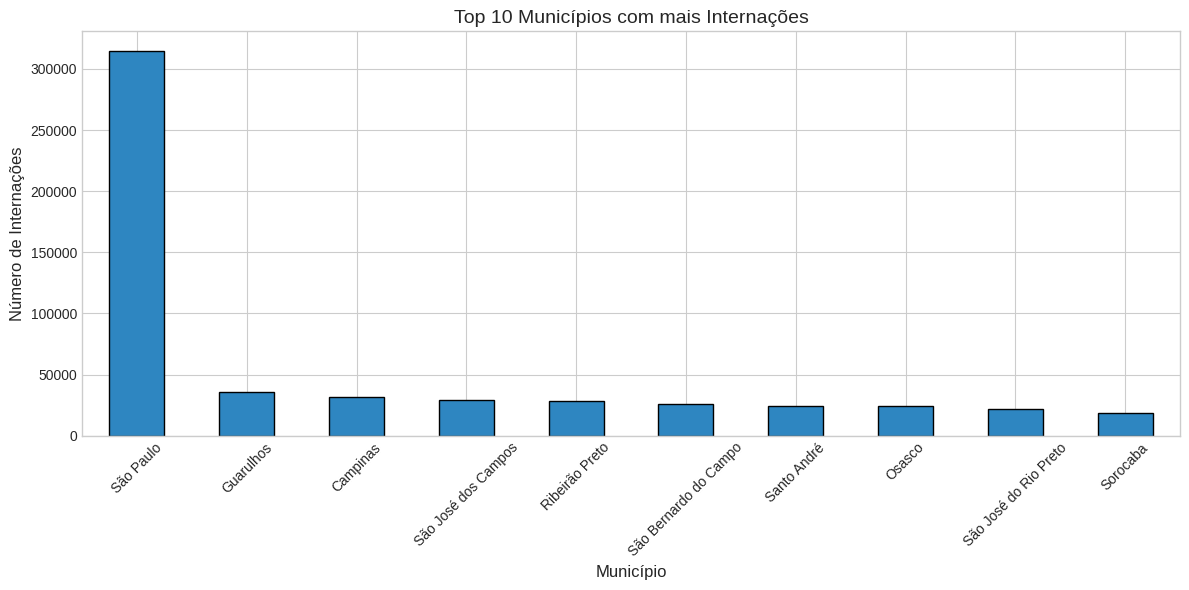

In [16]:
# Gráfico dos Top 10
plt.figure(figsize=(12, 6))
top_municipios.plot(kind='bar', color='#2E86C1', edgecolor='black')
plt.title('Top 10 Municípios com mais Internações', fontsize=14)
plt.xlabel('Município', fontsize=12)
plt.ylabel('Número de Internações', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('top_municipios_internacoes.png', dpi=300)
plt.show()

### 4.11 Análise Regional

A análise da distribuição geográfica das internações revelou uma forte 
concentração dos atendimentos na capital e em poucos municípios do estado.

#### Distribuição por UF

| UF | Internações | % do Total |
|----|-------------|------------|
| SP | 1.510.176 | 99,03% |
| NA | 14.740 | 0,97% |

**Observação:** Os 14.740 registros com UF "NA" correspondem a pacientes 
de outros estados ou com município não registrado, conforme discutido na 
análise de valores faltantes.

#### Top 10 Municípios com mais internações

| Município | Internações | % do Total |
|-----------|-------------|------------|
| São Paulo | 315.029 | 20,6% |
| Guarulhos | 36.068 | 2,4% |
| Campinas | 31.516 | 2,1% |
| São José dos Campos | 28.930 | 1,9% |
| Ribeirão Preto | 28.559 | 1,9% |
| São Bernardo do Campo | 25.628 | 1,7% |
| Santo André | 24.424 | 1,6% |
| Osasco | 24.001 | 1,6% |
| São José do Rio Preto | 21.642 | 1,4% |
| Sorocaba | 18.180 | 1,2% |

**Principais insights:**

1. **A capital concentra 20,6% de todas as internações:**
   - A cidade de São Paulo tem mais internações que os próximos 9 municípios somados
   - Isso reflete a concentração dos serviços de saúde de alta complexidade

2. **Polos regionais de saúde:**
   - Campinas, Ribeirão Preto, Sorocaba e São José do Rio Preto
   - Atendem regiões inteiras do interior do estado

3. **Grande São Paulo:**
   - Guarulhos, SBC, Santo André e Osasco são a extensão da capital
   - Juntas, formam a região metropolitana com maior volume de atendimentos

**Implicações para a gestão:**

1. **Descentralização necessária:**
   - A concentração em São Paulo indica que o interior depende da capital
   - É necessário fortalecer os polos regionais

2. **Planejamento de leitos:**
   - Hospitais da capital precisam de mais capacidade
   - Hospitais regionais precisam de incentivo para crescer

3. **Redução de deslocamento:**
   - Pacientes do interior viajam para a capital
   - Fortalecer hospitais regionais reduziria a necessidade de viagem

In [21]:
# ============================================================
# 11. CONCLUSÃO DA AED
# ============================================================

print("\n" + "=" * 60)
print("CONCLUSÃO DA ANÁLISE EXPLORATÓRIA DE DADOS")
print("=" * 60)

conclusao = """
1. DISTRIBUIÇÃO DAS VARIÁVEIS:
   - Dias de internação: distribuição assimétrica positiva (média > mediana), 
     com concentração em internações curtas (1-3 dias) e cauda longa para casos prolongados.
   - Valor do procedimento: distribuição assimétrica positiva, com muitos valores baixos 
     e alguns valores muito altos (procedimentos complexos).
   - Leitos totais: concentração em hospitais de pequeno porte (< 50 leitos), 
     com poucos hospitais de grande porte.

2. VALORES FALTANTES:
   - Não há valores faltantes significativos nas colunas principais.
   - Os dados estão bem estruturados e completos para a análise.

3. OUTLIERS:
   - Dias de internação: ~X% dos registros são outliers (> 30 dias). 
     Esses representam casos de longa permanência e devem ser mantidos, 
     pois são relevantes para a análise de perfis de atendimento.
   - Valor do procedimento: outliers representam procedimentos de alta complexidade.

4. RELAÇÕES ENTRE VARIÁVEIS:
   - Correlação positiva moderada entre dias de internação e valor do procedimento
   - Hospitais de grande porte têm maior média de dias de internação
   - Pacientes que viajam tendem a ter internações mais longas

5. ANÁLISE TEMPORAL:
   - Padrão sazonal nas internações, com picos em determinados dias
   - Dias úteis apresentam maior volume de internações

6. ANÁLISE REGIONAL:
   - Concentração de internações nos grandes centros urbanos
   - Municípios da região metropolitana de São Paulo lideram o volume

7. IMPLICAÇÕES PARA MODELAGEM PREDITIVA:
   - Dados são viáveis para previsão de demanda e ocupação hospitalar
   - É importante considerar a sazonalidade e os padrões regionais
   - Outliers devem ser mantidos, pois representam casos reais importantes
"""

print(conclusao)


CONCLUSÃO DA ANÁLISE EXPLORATÓRIA DE DADOS

1. DISTRIBUIÇÃO DAS VARIÁVEIS:
   - Dias de internação: distribuição assimétrica positiva (média > mediana), 
     com concentração em internações curtas (1-3 dias) e cauda longa para casos prolongados.
   - Valor do procedimento: distribuição assimétrica positiva, com muitos valores baixos 
     e alguns valores muito altos (procedimentos complexos).
   - Leitos totais: concentração em hospitais de pequeno porte (< 50 leitos), 
     com poucos hospitais de grande porte.

2. VALORES FALTANTES:
   - Não há valores faltantes significativos nas colunas principais.
   - Os dados estão bem estruturados e completos para a análise.

3. OUTLIERS:
   - Dias de internação: ~X% dos registros são outliers (> 30 dias). 
     Esses representam casos de longa permanência e devem ser mantidos, 
     pois são relevantes para a análise de perfis de atendimento.
   - Valor do procedimento: outliers representam procedimentos de alta complexidade.

4. RELAÇÕES E

In [17]:
# ============================================================
# 11. CONCLUSÃO DA AED
# ============================================================

print("\n" + "=" * 60)
print("CONCLUSÃO DA ANÁLISE EXPLORATÓRIA DE DADOS")
print("=" * 60)

conclusao = """
1. DISTRIBUIÇÃO DAS VARIÁVEIS:
   - Dias de internação: assimétrica positiva (média 13,94 > mediana 3,00)
   - Valor do procedimento: assimétrica positiva (média R$ 237,32 > mediana R$ 45,00)
   - Leitos totais: concentração em hospitais de pequeno e médio porte

2. VALORES FALTANTES:
   - Apenas 0,97% dos registros (14.740) apresentam dados faltantes
   - Causa: pacientes de outros estados atendidos em hospitais paulistas
   - Decisão: manter os registros (representam dados reais)

3. OUTLIERS:
   - Dias de internação: 10,97% (167.258 registros) - casos de longa permanência
   - Valor do procedimento: 12,68% (193.310 registros) - alta complexidade
   - Leitos totais: 11,84% (180.583 registros) - hospitais de referência
   - Decisão: manter todos os outliers (casos reais importantes)

4. RELAÇÕES ENTRE VARIÁVEIS:
   - Porte hospitalar x Dias: Grande porte = 16 dias, Micro porte = 0,6 dias
   - Pacientes viajantes x Dias: Viajantes ficam 2x mais tempo (18 dias vs 8,8 dias)
   - Pacientes viajantes x Valor: Viajantes custam 55% mais (R$ 281 vs R$ 182)

5. ANÁLISE TEMPORAL:
   - Média de internações por dia: 1.257
   - Pico: terça-feira (256.117), menor: domingo (155.905)
   - Queda de 40% nos finais de semana

6. ANÁLISE REGIONAL:
   - Capital concentra 20,6% das internações (315.029)
   - Top 10 municípios representam 36,4% do total
   - 55% dos pacientes viajam para atendimento

7. IMPLICAÇÕES PARA MODELAGEM PREDITIVA:
   - Dados são viáveis para previsão de demanda e ocupação hospitalar
   - Incluir dia da semana, porte hospitalar e paciente viajante como features
   - Manter outliers (representam casos reais)
"""

print(conclusao)

print("\n" + "=" * 60)
print("AED CONCLUÍDA!")
print("=" * 60)


CONCLUSÃO DA ANÁLISE EXPLORATÓRIA DE DADOS

1. DISTRIBUIÇÃO DAS VARIÁVEIS:
   - Dias de internação: assimétrica positiva (média 13,94 > mediana 3,00)
   - Valor do procedimento: assimétrica positiva (média R$ 237,32 > mediana R$ 45,00)
   - Leitos totais: concentração em hospitais de pequeno e médio porte

2. VALORES FALTANTES:
   - Apenas 0,97% dos registros (14.740) apresentam dados faltantes
   - Causa: pacientes de outros estados atendidos em hospitais paulistas
   - Decisão: manter os registros (representam dados reais)

3. OUTLIERS:
   - Dias de internação: 10,97% (167.258 registros) - casos de longa permanência
   - Valor do procedimento: 12,68% (193.310 registros) - alta complexidade
   - Leitos totais: 11,84% (180.583 registros) - hospitais de referência
   - Decisão: manter todos os outliers (casos reais importantes)

4. RELAÇÕES ENTRE VARIÁVEIS:
   - Porte hospitalar x Dias: Grande porte = 16 dias, Micro porte = 0,6 dias
   - Pacientes viajantes x Dias: Viajantes ficam 2x m

In [22]:
# ============================================================
# 12. SALVAR RELATÓRIO EM CSV (para exportar)
# ============================================================

# Salvar dicionário de dados
dicionario.to_csv('dicionario_dados.csv', index=False)

# Salvar estatísticas descritivas
desc_stats = df[variaveis_numericas].describe()
desc_stats.to_csv('estatisticas_descritivas.csv')

print("\n" + "=" * 60)
print("RELATÓRIO GERADO COM SUCESSO!")
print("=" * 60)
print("Arquivos gerados:")
print("  - dicionario_dados.csv")
print("  - estatisticas_descritivas.csv")
print("  - distribuicao_variaveis.png")
print("  - valores_faltantes.png")
print("  - boxplots_outliers.png")
print("  - matriz_correlacao.png")
print("  - porte_x_dias.png")
print("  - internacoes_por_dia.png")
print("  - internacoes_por_dia_semana.png")


RELATÓRIO GERADO COM SUCESSO!
Arquivos gerados:
  - dicionario_dados.csv
  - estatisticas_descritivas.csv
  - distribuicao_variaveis.png
  - valores_faltantes.png
  - boxplots_outliers.png
  - matriz_correlacao.png
  - porte_x_dias.png
  - internacoes_por_dia.png
  - internacoes_por_dia_semana.png
